# fMRI Denoising Pipeline - Example Usage

This notebook demonstrates how to use the denoising pipeline to extract time-series from BOLD fMRI data.

In [4]:
import sys
sys.path.append('..')  # Add parent directory to path

from denoising import DenoisingPipeline
from denoising.config import load_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [ ]:
!pip install pybids --index-url https://pypi-mirror.gitverse.ru/simple/

## 1. Load Configuration

First, load the configuration file that defines atlas, denoising, and confounds parameters.

In [5]:
config = load_config('../configs/strategy_4.yaml')

print(f"Atlas: {config.atlas.name} with {config.atlas.n_regions} regions")
print(f"Smoothing FWHM: {config.denoising.smoothing_fwhm} mm")
print(f"Standardization: {config.denoising.standardize}")
print(f"Standardization OF CONFOUNDS: {config.denoising.standardize_confounds}")

Atlas: schaefer_2018 with 400 regions
Smoothing FWHM: 4.0 mm
Standardization: None
Standardization OF CONFOUNDS: True


In [7]:
config.denoising.standardize = 'zscore_sample'

## 2. Initialize Pipeline

Create a `DenoisingPipeline` instance with the configuration.

In [8]:
pipeline = DenoisingPipeline(config)
print("Pipeline initialized successfully")

Pipeline initialized successfully


## 3. Process a Single Subject

Specify paths to BOLD and confounds files, then run the pipeline.

In [9]:
# Update these paths to your data
bold_path = r"/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29006/ses-1/func/sub-29006_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"
output_dir = "../output"

# Run the pipeline
timeseries = pipeline.process_subject(bold_path, output_dir)
timeseries.head()

[fetch_atlas_schaefer_2018] Dataset found in /home/tm/nilearn_data/schaefer_2018


,7Networks_LH_Vis_1,7Networks_LH_Vis_2,7Networks_LH_Vis_3,7Networks_LH_Vis_4,7Networks_LH_Vis_5,7Networks_LH_Vis_6,7Networks_LH_Vis_7,7Networks_LH_Vis_8,7Networks_LH_Vis_9,7Networks_LH_Vis_10,...,7Networks_RH_Default_PFCdPFCm_13,7Networks_RH_Default_pCunPCC_1,7Networks_RH_Default_pCunPCC_2,7Networks_RH_Default_pCunPCC_3,7Networks_RH_Default_pCunPCC_4,7Networks_RH_Default_pCunPCC_5,7Networks_RH_Default_pCunPCC_6,7Networks_RH_Default_pCunPCC_7,7Networks_RH_Default_pCunPCC_8,7Networks_RH_Default_pCunPCC_9
0,-0.633831,-0.695522,-0.960204,-0.782065,-0.466201,-0.191201,0.057810,-0.255523,-0.328968,-0.278831,...,0.274736,0.231329,-0.009406,0.517337,0.423592,0.614383,0.506047,0.228919,0.389677,0.098959
1,0.133021,0.714505,-0.202888,-0.294541,-1.107785,-0.409729,0.739597,0.293551,-0.140776,-0.614180,...,-0.668493,-0.832060,-0.120711,0.245073,-0.900792,-0.063202,0.408263,0.197315,0.810072,0.293104
2,0.456849,0.138447,0.408787,0.196926,0.011039,0.482841,0.073205,0.111724,0.316184,-0.100076,...,-0.071296,-0.606508,0.560123,0.421826,-0.241413,0.340695,0.317445,0.452524,0.695698,0.251877
3,0.177293,-1.431931,0.341464,0.197517,1.323461,1.031015,-0.771312,-0.763030,0.600081,-0.005794,...,1.278028,-0.130072,0.660731,0.595496,0.854645,1.018625,-0.006571,0.072298,0.151829,0.074169
4,-0.473004,-1.555046,-0.474205,-0.502781,0.583321,-0.001684,-0.400897,-1.214648,0.391347,-0.900838,...,1.227010,-0.487621,-0.599776,0.191185,0.492583,0.601803,-0.387089,-0.970634,-0.277465,-0.190238


## 5. Visualize Time-Series

Plot time-series for a few regions.

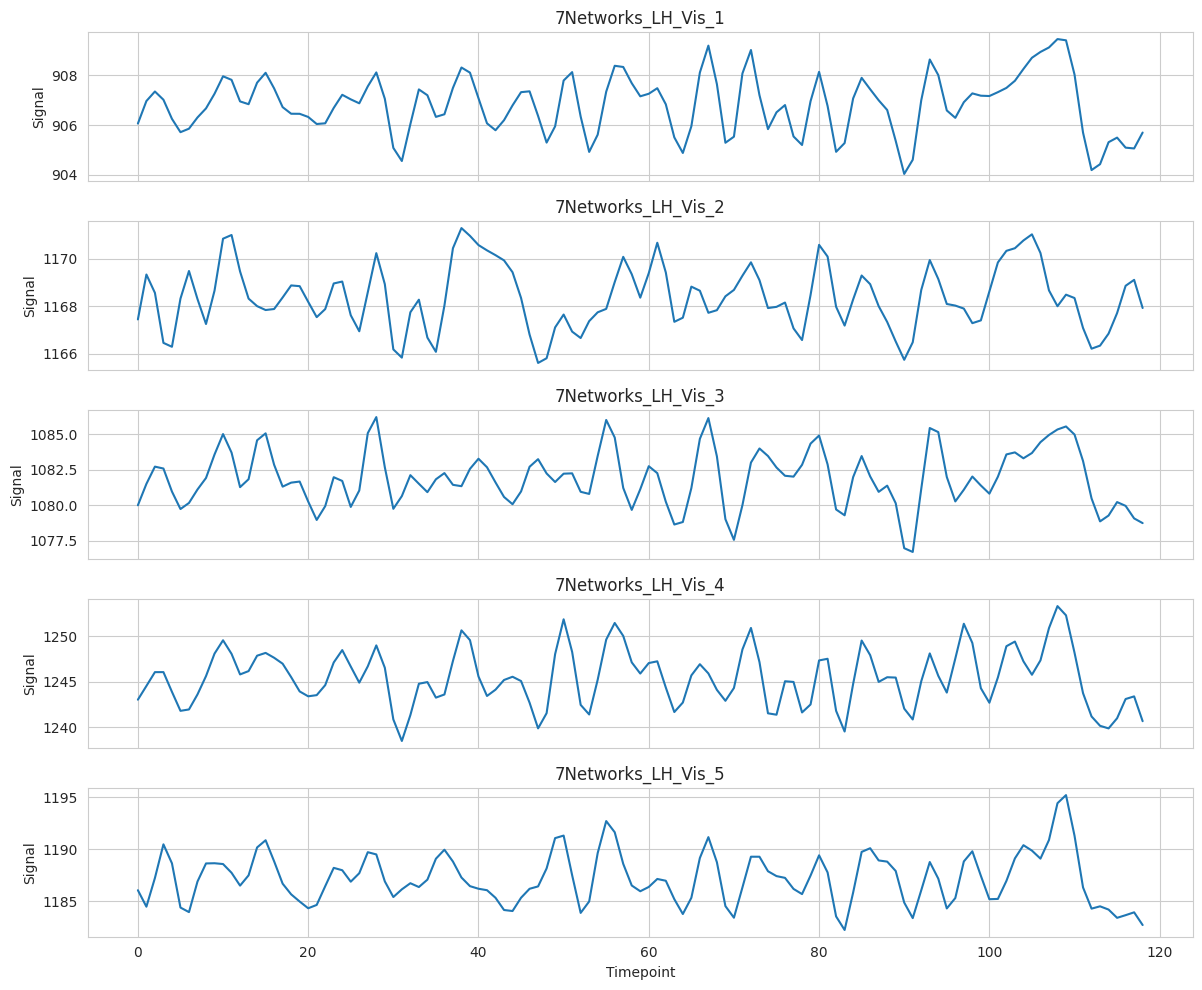

In [ ]:
# Plot first 5 regions
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i, ax in enumerate(axes):
    region = timeseries.columns[i]
    ax.plot(timeseries[region].values)
    ax.set_ylabel('Signal')
    ax.set_title(region)

axes[-1].set_xlabel('Timepoint')
plt.tight_layout()
plt.show()

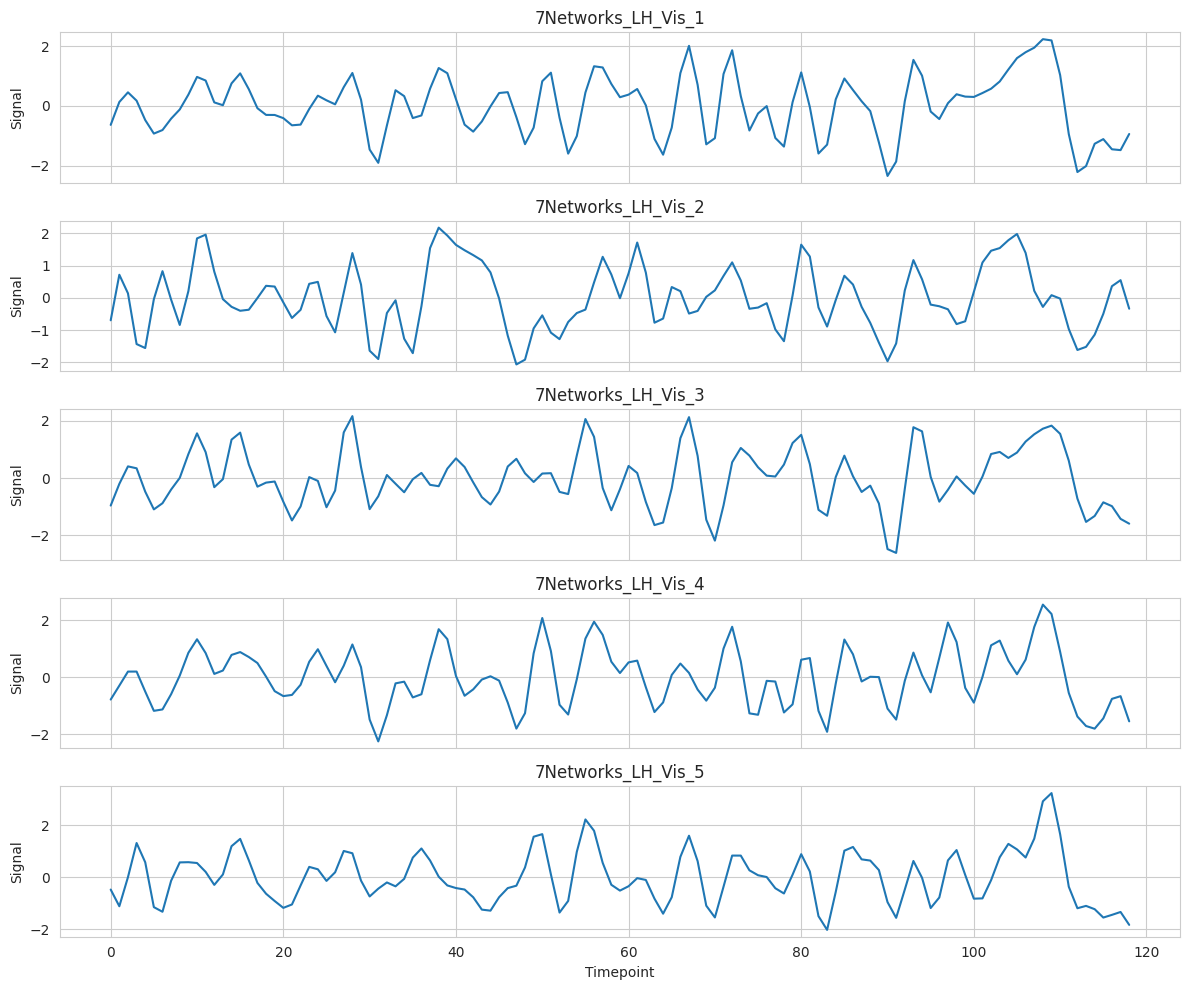

In [10]:
# Plot first 5 regions
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i, ax in enumerate(axes):
    region = timeseries.columns[i]
    ax.plot(timeseries[region].values)
    ax.set_ylabel('Signal')
    ax.set_title(region)

axes[-1].set_xlabel('Timepoint')
plt.tight_layout()
plt.show()

## 6. Correlation Matrix

Compute and visualize the correlation matrix between regions.

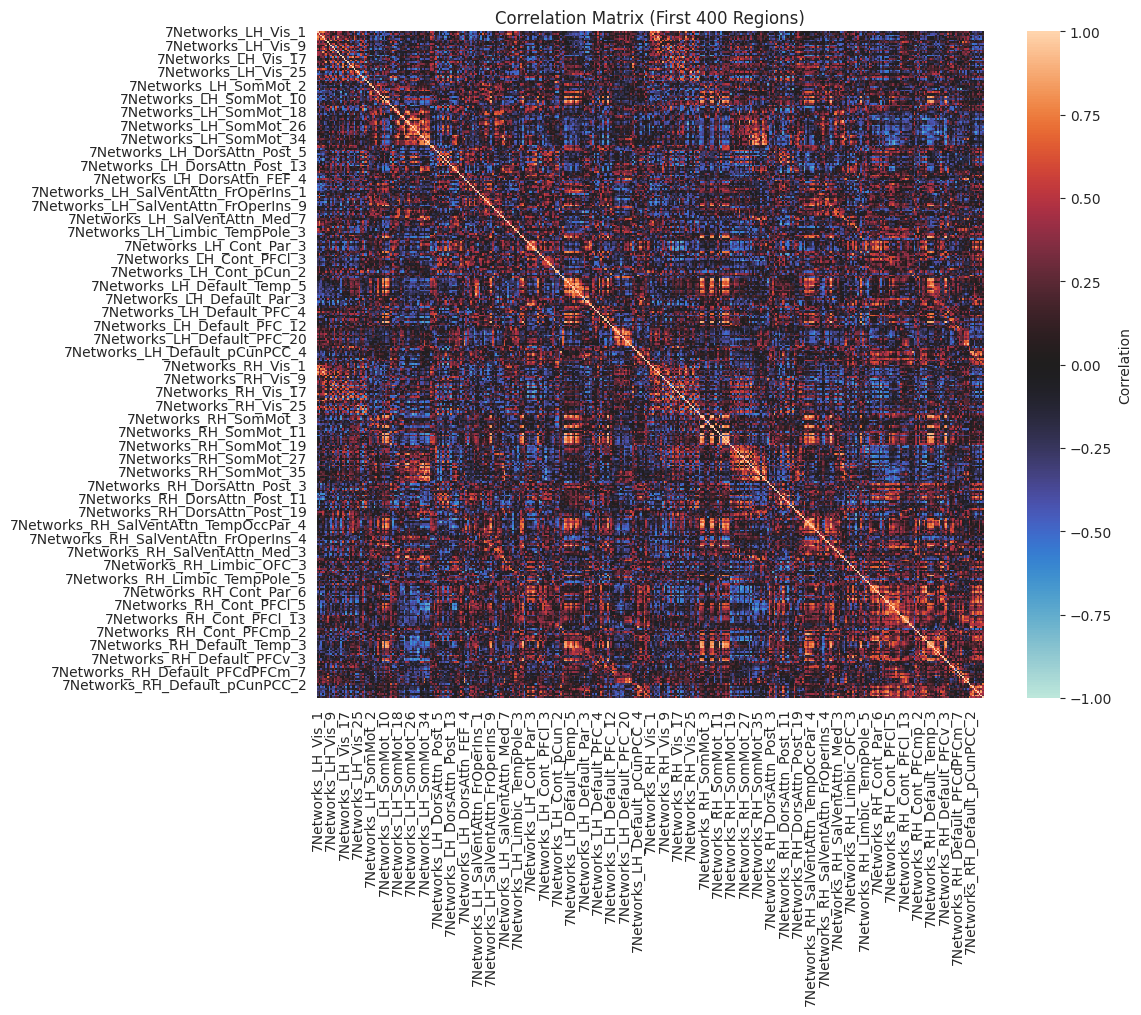

In [11]:
# Compute correlation matrix (subset of regions for visualization)
n_regions_plot = 400
corr_matrix = timeseries.iloc[:, :n_regions_plot].corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, center=0, vmin=-1, vmax=1, 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix (First {n_regions_plot} Regions)')
plt.tight_layout()
plt.show()

## 7. Batch Processing (Legacy Mode)

Process multiple subjects using a list of file paths.

In [8]:
# Define subjects to process
subjects = [
    {
        "bold_path": "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29006/ses-1/func/sub-29006_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
    },
    {
        "bold_path": "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives/sub-29007/ses-1/func/sub-29007_ses-1_task-rest_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz",
    }
]
output_dir = "../output"
# Run batch processing
outputs = pipeline.process_batch(subjects, output_dir)
# print(f"Processed {len([o for o in outputs if o])} subjects successfully")

In [9]:
print(f"Processed {len([o for o in outputs if o])} subjects successfully")


Processed 2 subjects successfully


## 8. BIDS Mode Processing

Process subjects using BIDS dataset structure. This mode automatically handles multiple sessions and runs.

In [6]:
from denoising.io.file_handler import BIDSFileLoader
from denoising.config.schemas import BIDSConfig

# Define BIDS dataset path and parameters
bids_path = "/data/Projects/ABIDE2/ABIDEII-BNI_1/derivatives"  # Update this path

# Create BIDS file loader
bids_loader = BIDSFileLoader(bids_path)

# Get all subjects in the dataset
#all_subjects = bids_loader.get_all_subjects()
#print(f"Found {len(all_subjects)} subjects in dataset")
#print(f"Subjects: {all_subjects[:5]}...")  # Show first 5

ValueError: BIDS root does not exist: c:\data\Projects\ABIDE2\ABIDEII-BNI_1\derivatives

In [5]:
# IMPORTANT: Specify a writable output directory!
# Do NOT use the BIDS dataset path if it's read-only
output_dir = "../output"  # Or any writable directory

# Process a single subject (all sessions/runs)
#subject_id = ['29006', '29007', '29008', '29009',] # Update with actual subject ID
subject_id = 'all'
outputs = pipeline.process_batch(subject_id, output_dir=output_dir, bids_loader=bids_loader)

print(f"\nProcessed {len(outputs)} files for subject {subject_id}")

  0%|          | 0/58 [00:00<?, ?it/s]

[fetch_atlas_schaefer_2018] Dataset found in /home/tm/nilearn_data/schaefer_2018


KeyboardInterrupt: 

In [12]:
# Process multiple subjects
subjects_to_process = ["29006", "29007", "29008"]  # Update with actual subject IDs
outputs = pipeline.process_batch(subjects_to_process, output_dir=output_dir, bids_loader=bids_loader)

print(f"\nProcessed {len(outputs)} files across {len(subjects_to_process)} subjects")
successful = [o for o in outputs if o]
print(f"Successful: {len(successful)}/{len(outputs)}")

### Output Directory Structure

In BIDS mode, outputs are saved in a BIDS-compliant structure:
```
{output_dir}/
├── sub-{subject}/
│   ├── ses-{session}/
│   │   └── time-series/
│   │       └── {subject}_{session}_{task}_{run}_atlas-{atlas_name}.csv
│   └── time-series/
│       └── {subject}_{task}_{run}_atlas-{atlas_name}.csv
```

**Important:** The `output_dir` must be a writable directory. Do not use the BIDS dataset path if it's read-only (e.g., shared storage). Instead, specify a local writable directory like `./output` or `~/fmri_results`.